In [27]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

In [5]:
def read_iob(file_path):
    sentences, labels = [], []
    tokens, tags = [], []
    header_pattern = re.compile(r"^###MEDLINE:\d+")

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:  # new sentence
                if tokens:
                    sentences.append(tokens)
                    labels.append(tags)
                    tokens, tags = [], []
                continue

            if header_pattern.match(line):
                continue

            parts = line.split()
            if len(parts) == 2:
                word, tag = parts
                tokens.append(word)
                tags.append(tag)

        # last sentence
        if tokens:
            sentences.append(tokens)
            labels.append(tags)

    return sentences, labels

files = ["Genia4EReval1.iob2", "Genia4EReval2.iob2", "Genia4ERtask1.iob2", "Genia4ERtask2.iob2"]

all_sentences, all_labels = [], []

for file in files:
    sents, labs = read_iob(file)
    all_sentences.extend(sents)
    all_labels.extend(labs)
    
data = []
for sent, tags in zip(all_sentences, all_labels):
    for token, tag in zip(sent, tags):
        data.append((token, tag))

df = pd.DataFrame(data, columns=["token", "tag"])
df.head()

,token,tag
0,Number,O
1,of,O
2,glucocorticoid,B-protein
3,receptors,I-protein
4,in,O


In [10]:
total_sentences = len(all_sentences)
total_tokens = len(df)
unique_tokens = df['token'].nunique()

print(f"Total sentences: {total_sentences}")
print(f"Total tokens: {total_tokens}")
print(f"Unique tokens: {unique_tokens}")

Total sentences: 44776
Total tokens: 1186488
Unique tokens: 25103


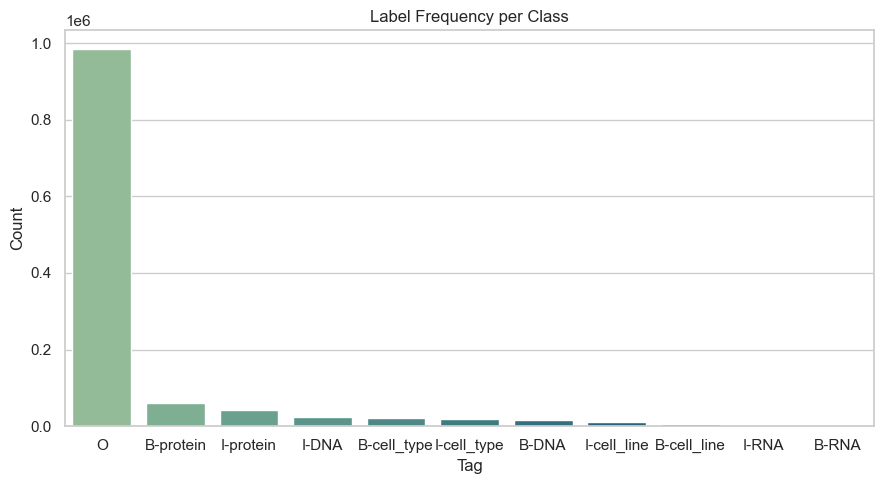

tag
O              984432
B-protein       61262
I-protein       43016
I-DNA           22918
B-cell_type     20764
I-cell_type     17958
B-DNA           14916
I-cell_line      9530
B-cell_line      6366
I-RNA            3064
B-RNA            2262
Name: count, dtype: int64


In [31]:
tag_counts = df['tag'].value_counts()

plt.figure(figsize=(9, 5))
sns.barplot(x=tag_counts.index, y=tag_counts.values, palette="crest")
plt.title("Label Frequency per Class")
plt.ylabel("Count")
plt.xlabel("Tag")
plt.tight_layout()
plt.show()

print(tag_counts)

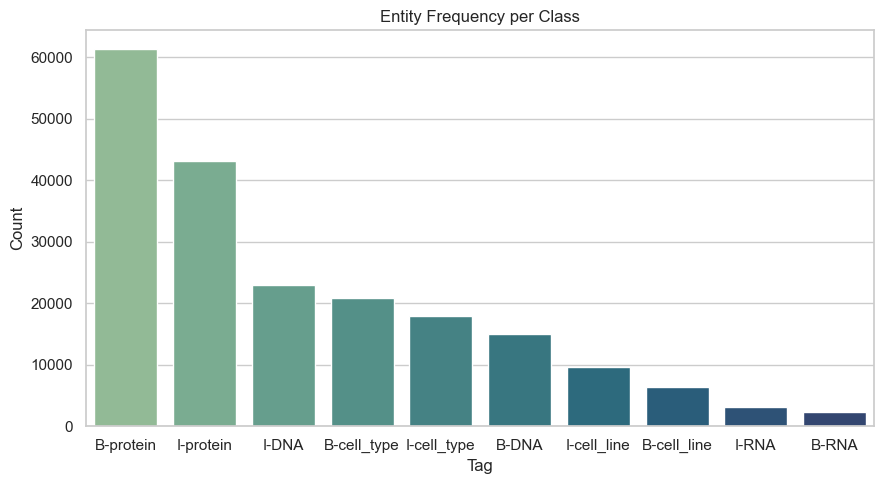

tag
B-protein      61262
I-protein      43016
I-DNA          22918
B-cell_type    20764
I-cell_type    17958
B-DNA          14916
I-cell_line     9530
B-cell_line     6366
I-RNA           3064
B-RNA           2262
Name: count, dtype: int64


In [29]:
entity_only = df[df['tag'] != 'O']
tag_counts = entity_only['tag'].value_counts()

plt.figure(figsize=(9, 5))
sns.barplot(x=tag_counts.index, y=tag_counts.values, palette="crest")
plt.title("Entity Frequency per Class")
plt.ylabel("Count")
plt.xlabel("Tag")
plt.tight_layout()
plt.show()

print(tag_counts)

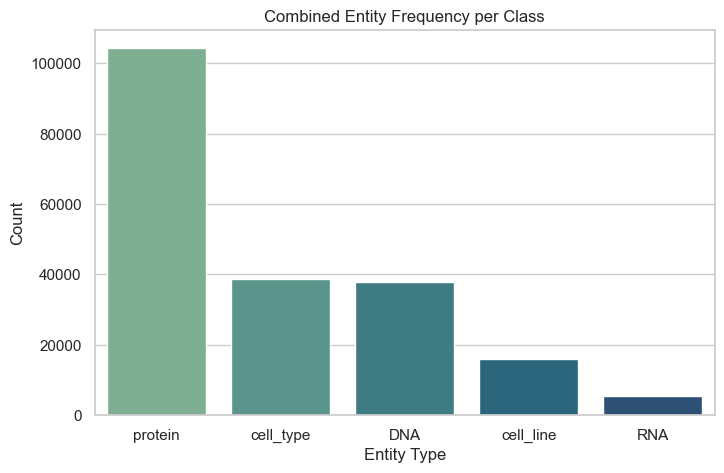

In [32]:
entity_types = [t.split('-')[-1] for t in df['tag'] if t != 'O']
entity_counts = Counter(entity_types)

plt.figure(figsize=(8, 5))
sns.barplot(x=list(entity_counts.keys()), y=list(entity_counts.values()), palette="crest")
plt.title("Combined Entity Frequency per Class")
plt.ylabel("Count")
plt.xlabel("Entity Type")
plt.show()

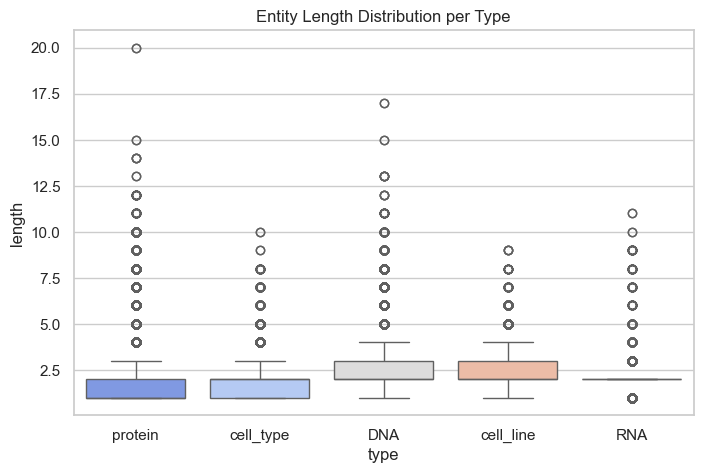

In [35]:
entity_spans = []
for tags, sent in zip(all_labels, all_sentences):
    i = 0
    while i < len(tags):
        if tags[i].startswith('B-'):
            entity_type = tags[i][2:]
            length = 1
            i += 1
            while i < len(tags) and tags[i].startswith('I-') and tags[i][2:] == entity_type:
                length += 1
                i += 1
            entity_spans.append((entity_type, length))
        else:
            i += 1

entity_df = pd.DataFrame(entity_spans, columns=['type', 'length'])

plt.figure(figsize=(8, 5))
sns.boxplot(x='type', y='length', data=entity_df, palette='coolwarm')
plt.title("Entity Length Distribution per Type")
plt.show()

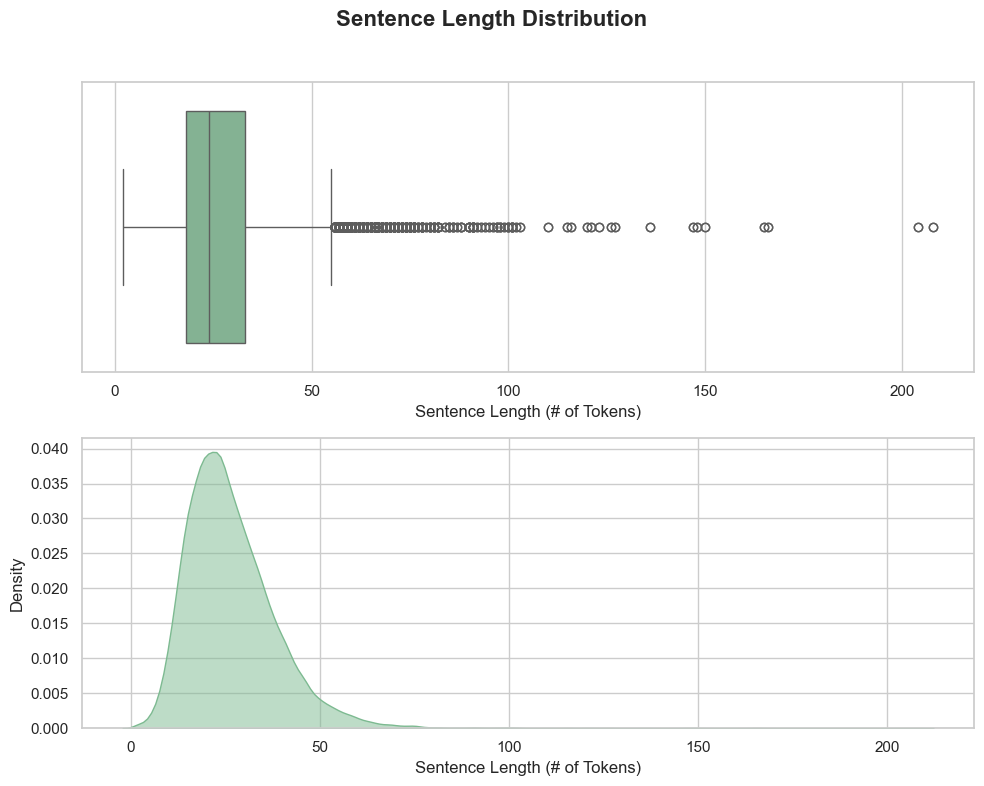

In [50]:
sentence_lengths = [len(s) for s in all_sentences]

plt.figure(figsize=(10, 8))
plt.suptitle("Sentence Length Distribution", fontsize=16, weight="bold")

plt.subplot(2, 1, 1)
sns.boxplot(x=sentence_lengths, color=sns.color_palette("crest")[0])
plt.xlabel("Sentence Length (# of Tokens)")
plt.ylabel("")

plt.subplot(2, 1, 2)
sns.kdeplot(sentence_lengths, fill=True, color=sns.color_palette("crest")[0], alpha=0.5)
plt.xlabel("Sentence Length (# of Tokens)", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [51]:
entity_tokens = df[df['tag'] != 'O']['token']
non_entity_tokens = df[df['tag'] == 'O']['token']

print("Most common entity tokens:")
print(entity_tokens.value_counts().head(10))

print("\nMost common non-entity tokens:")
print(non_entity_tokens.value_counts().head(10))

Most common entity tokens:
token
cells       10140
B            5892
T            5770
human        4084
cell         3862
gene         3252
factor       2750
NF-kappa     2678
protein      2658
receptor     2418
Name: count, dtype: int64

Most common non-entity tokens:
token
of     50686
the    47034
.      44396
,      43452
and    31578
in     30928
to     17684
)      15658
(      15546
a      15442
Name: count, dtype: int64


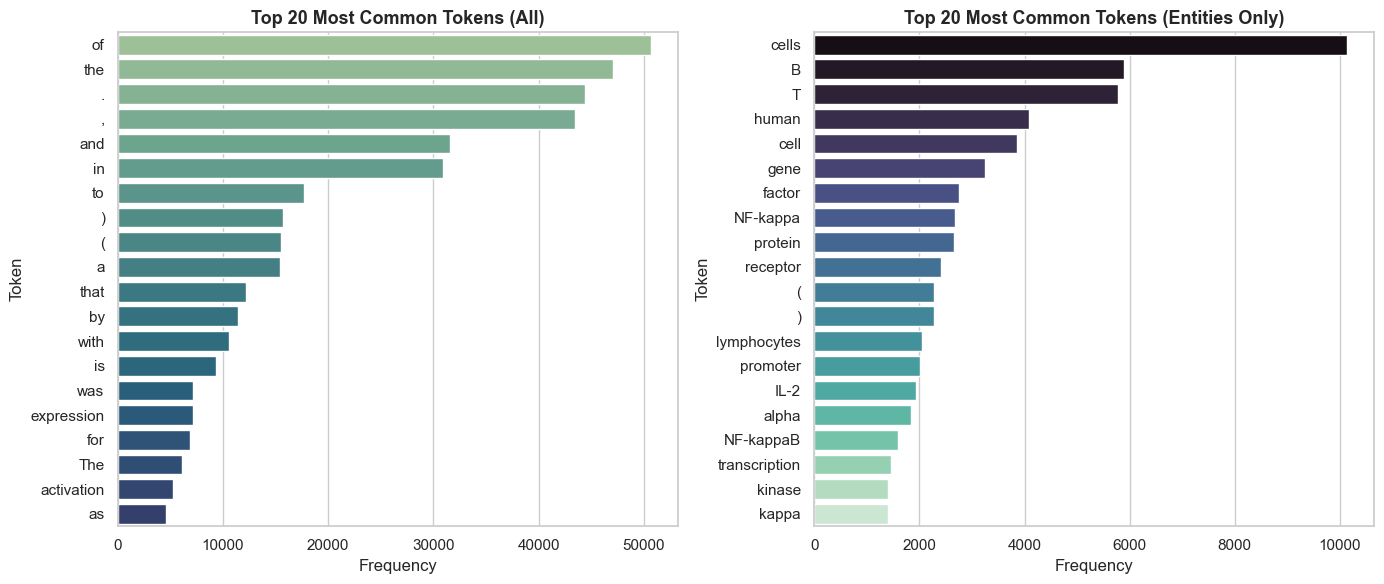

In [80]:
entity_tokens = df[df['tag'] != 'O']['token']
non_entity_tokens = df[df['tag'] == 'O']['token']

entity_counts = Counter(entity_tokens).most_common(20)
non_entity_counts = Counter(non_entity_tokens).most_common(20)
entity_df = pd.DataFrame(entity_counts, columns=["Token", "Frequency"])
non_entity_df = pd.DataFrame(non_entity_counts, columns=["Token", "Frequency"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=non_entity_df, x="Frequency", y="Token", ax=axes[0], palette="crest")
axes[0].set_title("Top 20 Most Common Tokens (All)", fontsize=13, weight="bold")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Token")

sns.barplot(data=entity_df, x="Frequency", y="Token", ax=axes[1], palette="mako")
axes[1].set_title("Top 20 Most Common Tokens (Entities Only)", fontsize=13, weight="bold")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Token")

plt.tight_layout()
plt.show()

In [83]:
# Checking for invalid NER tagging, there shouldn't be any tbh

invalid_sequences = 0
for tags in all_labels:
    for i in range(1, len(tags)):
        if tags[i].startswith("I-") and (tags[i-1] == "O" or tags[i-1][2:] != tags[i][2:]):
            invalid_sequences += 1

print("Number of invalid sequences: invalid_sequences

0

In [84]:
all_tokens = [token for sent in all_sentences for token in sent]

# --- Summary table ---
num_sentences = len(all_sentences)
num_tokens = len(all_tokens)
avg_len = sum(len(s) for s in all_sentences) / num_sentences
vocab = set(all_tokens)
vocab_size = len(vocab)
max_len = max(len(s) for s in all_sentences)
min_len = min(len(s) for s in all_sentences)

summary_df = pd.DataFrame({
    "Metric": ["Number of sentences", "Total tokens", "Average sentence length", "Vocabulary size", "Max sentence length", "Min sentence length", "Invalid Sequence"],
    "Value": [num_sentences, num_tokens, round(avg_len, 2), vocab_size, max_len, min_len, invalid_sequences]
})

summary_df

,Metric,Value
0,Number of sentences,44776.0
1,Total tokens,1186488.0
2,Average sentence length,26.5
3,Vocabulary size,25103.0
4,Max sentence length,208.0
5,Min sentence length,2.0
6,Invalid Sequence,0.0
